# Causal Analysis: AI Exposure, Wages, and Unemployment

This notebook studies whether workers in more AI-exposed industries experienced different post-GenAI changes in unemployment and wage income, and whether those effects differ between early-career and older workers.


## Research Question

Main question: did workers in more AI-exposed industries experience different post-GenAI changes in wages and unemployment?

Heterogeneity question: were younger and earlier-career workers affected differently from older workers?

Because `AIIE` is a time-invariant industry-level exposure measure, the identifying variation in this notebook comes from the interaction of industry AI exposure with the common post-GenAI period.


## Identification Strategy

We use a repeated-cross-section difference-in-differences design built from CPS ASEC March samples merged to industry-level `AIIE`.

The treatment is not `AIIE` by itself. Instead, treatment intensity is:

- `Post_t x AIIE_j`

where `t` indexes year and `j` indexes industry.

Interpretation: after the broad arrival of generative AI tools, did outcomes change more in industries with higher AI exposure than in industries with lower AI exposure?

Parallel Trends Assumption: without the GenAI shock, outcomes in higher- and lower-exposure industries would have evolved similarly over time.


## Setup and Imports


In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in [Path.cwd(), Path.cwd().parent]:
    if (candidate / "notebook_helpers.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find notebook_helpers.py")

from notebook_helpers import (
    coef_table,
    extract_event_study_table,
    fit_event_study,
    joint_zero_test,
    plot_event_study,
    plot_event_study_on_axis,
    plot_trends,
    run_wls,
    save_figure,
    summarize_sample,
    wald_difference_test,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
DATA_PATH = Path("../data/data_with_aiie.csv")
data = pd.read_csv(DATA_PATH)

print(f"Loaded {len(data):,} rows from {DATA_PATH}")
data.head()

Loaded 1,528,045 rows from ../data/data_with_aiie.csv


,YEAR,SERIAL,MONTH,CPSID,ASECFLAG,ASECWTH,PERNUM,CPSIDP,CPSIDV,ASECWT,AGE,EMPSTAT,LABFORCE,OCC,IND,EDUC,INCWAGE,IND_2022,industry_desc,AIIE,occ_desc,AIOE
0,2016,2,3,20141202933700,1,"1,132.0500",1,20141202933701,201412029337011,"1,132.0500",79,36,1,0,0,30,0,0,NaN,NaN,NaN,NaN
1,2016,7,3,20151202935900,1,"1,077.5400",1,20151202935901,201512029359011,"1,077.5400",60,32,1,0,0,50,0,0,NaN,NaN,NaN,NaN
2,2016,7,3,20151202935900,1,"1,077.5400",2,20151202935902,201512029359021,"1,077.5400",59,32,1,0,0,81,0,0,NaN,NaN,NaN,NaN
3,2016,8,3,20160202937400,1,"1,151.4900",1,20160202937401,201602029374011,"1,151.4900",69,36,1,0,0,81,0,0,NaN,NaN,NaN,NaN
4,2016,9,3,20160102910900,1,705.0000,1,20160102910901,201601029109011,705.0000,24,21,2,9140,6190,73,6000,6190,Taxi and limousine service,1.3699,NaN,NaN


In [3]:
data["YEAR"].value_counts()

YEAR
2017    192456
2016    191769
2019    186601
2018    186490
2020    163469
2022    158346
2023    151552
2024    149784
2025    147578
Name: count, dtype: int64

## Timing Differs by Outcome

The CPS ASEC interviews occur in March of each survey year. That timing matters for the two outcomes in this notebook.

- Unemployment is measured close to the survey date, so we can use `2023-2025` as a reasonable post period.
- `INCWAGE` is prior-year annual wage income, so March 2023 mostly reflects 2022 earnings thus likely pre-dates widespread GenAI use.

For that reason we define:

- `post_unemp = 1` for `YEAR >= 2023`
- `post_wage = 1` for `YEAR >= 2024`

and treats 2023 as a transition year for the wage analysis.


## Define Our Sample

We want to restrict our analyses to prime-age workers, to avoid mixing in people in retirement, school. We also only want individuals in the labor force and that have positive income.

Generally,

- ages `25-64`
- non-missing `AIIE`

Outcome-specific samples:

- Unemployment sample: in the labor force
- Wage sample: employed with positive `INCWAGE`


## Defining Variables

- `AIIE`: continuous industry-level AI exposure measure
- `post_unemployment`: indicator for `YEAR >= 2023`
- `post_wage`: indicator for `YEAR >= 2024`
- `unemployed`: indicator for unemployed workers in the labor force
- `log_wage`: `log(INCWAGE)` for workers with positive wage income
- `early_career`: ages `25-34`
- `older_worker`: ages `50-64`

We define the following variables for plotting purposes:

- `high_exposure_group`: top quartile of `AIIE` for plots only
- `low_exposure_group`: bottom quartile of `AIIE` for plots only

Population averages and regressions are estimated using CPS ASEC survey weights.


In [4]:
df = data.copy()


# restrict age to working age population
df = df[df["AGE"].between(25, 64)].copy()

df = df[df["AIIE"].notna()].copy()

# use employment status coding from CPS/IPUMS convention
df["employed"] = df["EMPSTAT"].isin([10, 12]).astype(int)
df["unemployed"] = df["EMPSTAT"].isin([20, 21, 22]).astype(int)
df["in_labor_force"] = (df["LABFORCE"] == 2).astype(int)

# create indicators for post AIIE period, 2023 for unemployment and 2024 for wage (to reflect timing offset in CPS)
df["post_unemployment"] = (df["YEAR"] >= 2023).astype(int)
df["post_wage"] = (df["YEAR"] >= 2024).astype(int)

# age groups
df["early_career"] = df["AGE"].between(25, 34).astype(int)
df["older_worker"] = df["AGE"].between(50, 64).astype(int)

# wage outcome
df["positive_wage"] = (df["INCWAGE"] > 0).astype(int)
df["log_wage"] = np.where(df["INCWAGE"] > 0, np.log(df["INCWAGE"]), np.nan)

/Users/aeshagandhi/Downloads/MIDS-Sp26/UDS/UDS-Project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
# creative exposure groups for plots
q1 = df["AIIE"].quantile(0.25)
q3 = df["AIIE"].quantile(0.75)
df["exposure_group"] = np.select(
    [df["AIIE"] <= q1, df["AIIE"] >= q3],
    ["Low exposure", "High exposure"],
    default="Middle exposure",
)

# analysis samples
unemp_sample = df[df["in_labor_force"] == 1].copy()
wage_sample = df[(df["employed"] == 1) & (df["positive_wage"] == 1)].copy()
wage_did_sample = wage_sample[wage_sample["YEAR"] != 2023].copy()

print("Working-age rows with non-missing AIIE:", f"{len(df):,}")
print("Unemployment sample:", f"{len(unemp_sample):,}")
print("Wage sample:", f"{len(wage_sample):,}")
print(
    "Main wage DiD sample (excluding transition year 2023):",
    f"{len(wage_did_sample):,}",
)

Working-age rows with non-missing AIIE: 516,210
Unemployment sample: 512,842
Wage sample: 455,443
Main wage DiD sample (excluding transition year 2023): 409,973


### Helper Functions


In [6]:
from notebook_helpers import (
    weighted_mean,
    weighted_mean_se,
    summarize_sample,
    yearly_group_stats,
    smooth_segment,
    save_figure,
    plot_trends,
    run_wls,
    coef_table,
    wald_difference_test,
)


## Descriptive Statistics

check sample sizes, exposure coverage, and outcome patterns


In [7]:
coverage_table = pd.DataFrame(
    {
        "sample": [
            "Working-age analysis frame",
            "Unemployment sample",
            "Wage sample",
            "Main wage DiD sample",
        ],
        "n_rows": [len(df), len(unemp_sample), len(wage_sample), len(wage_did_sample)],
    }
)
coverage_table

,sample,n_rows
0,Working-age analysis frame,516210
1,Unemployment sample,512842
2,Wage sample,455443
3,Main wage DiD sample,409973


In [8]:
display(summarize_sample(unemp_sample, ["AIIE", "unemployed", "AGE"]))
display(summarize_sample(wage_sample, ["AIIE", "INCWAGE", "log_wage", "AGE"]))

,variable,mean,std,min,max,missing
0,AIIE,0.1365,1.1567,-1.9986,2.2156,0
1,unemployed,0.0362,0.1867,0.0000,1.0000,0
2,AGE,43.1917,10.7862,25.0000,64.0000,0


,variable,mean,std,min,max,missing
0,AIIE,0.1940,1.1496,-1.9986,2.2156,0
1,INCWAGE,"67,534.2531","81,493.3720",2.0000,"2,099,999.0000",0
2,log_wage,10.7564,0.8956,0.6931,14.5574,0
3,AGE,43.0997,10.7663,25.0000,64.0000,0


In [9]:
display(unemp_sample.groupby("YEAR").size().rename("unemployment_sample_n").to_frame())
display(wage_did_sample.groupby("YEAR").size().rename("wage_sample_n").to_frame())

,unemployment_sample_n
YEAR,
2016,63686
2017,64460
2018,62313
2019,63020
2020,54754
2022,52850
2023,50876
2024,50831
2025,50052


,wage_sample_n
YEAR,
2016,55908
2017,56881
2018,55256
2019,56276
2020,48316
2022,47023
2024,45466
2025,44847


In [10]:
unemp_pre_post = (
    unemp_sample[unemp_sample["exposure_group"].isin(["Low exposure", "High exposure"])]
    .groupby(["post_unemployment", "exposure_group"], observed=True)
    .apply(lambda g: weighted_mean(g["unemployed"], g["ASECWT"]))
    .reset_index(name="weighted_unemployment_rate")
)

wage_pre_post = (
    wage_did_sample[
        wage_did_sample["exposure_group"].isin(["Low exposure", "High exposure"])
    ]
    .groupby(["post_wage", "exposure_group"], observed=True)
    .apply(lambda g: weighted_mean(g["log_wage"], g["ASECWT"]))
    .reset_index(name="weighted_mean_log_wage")
)

display(unemp_pre_post)
display(wage_pre_post)

,post_unemployment,exposure_group,weighted_unemployment_rate
0,0,High exposure,0.0236
1,0,Low exposure,0.0593
2,1,High exposure,0.0217
3,1,Low exposure,0.0500


,post_wage,exposure_group,weighted_mean_log_wage
0,0,High exposure,10.9067
1,0,Low exposure,10.5270
2,1,High exposure,11.1769
3,1,Low exposure,10.7747


### Outcome Trends by AI Exposure

The first four plots use annual survey-weighted means, overlay separate LOWESS fits for the pre and post periods within each exposure group, and show 95% confidence bands around those annual means. This makes the descriptive evidence easier to read than raw year-to-year line connections while still showing uncertainty.


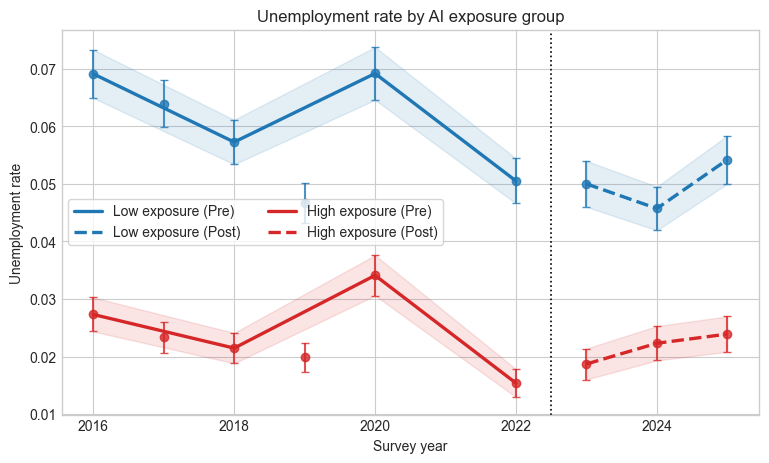

Saved causal_analysis_figures/01_weighted_unemployment_rate_by_ai_exposure_group.png


In [11]:
fig_unemp, ax_unemp, unemp_plot_df = plot_trends(
    unemp_sample,
    value_col="unemployed",
    title="Unemployment rate by AI exposure group",
    ylabel="Unemployment rate",
    post_start=2023,
)
plt.show()
save_figure(fig_unemp, "01_weighted_unemployment_rate_by_ai_exposure_group.png")


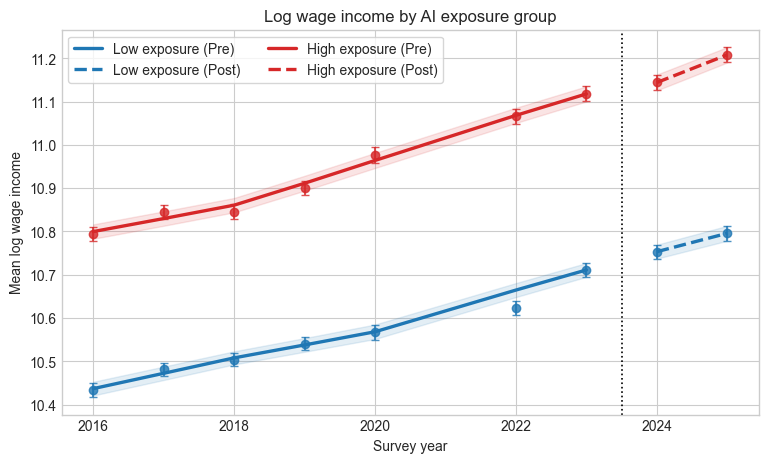

Saved causal_analysis_figures/02_weighted_log_wage_income_by_ai_exposure_group.png


In [12]:
fig_wage, ax_wage, wage_plot_df = plot_trends(
    wage_sample,
    value_col="log_wage",
    title="Log wage income by AI exposure group",
    ylabel="Mean log wage income",
    post_start=2024,
)
plt.show()
save_figure(fig_wage, "02_weighted_log_wage_income_by_ai_exposure_group.png")


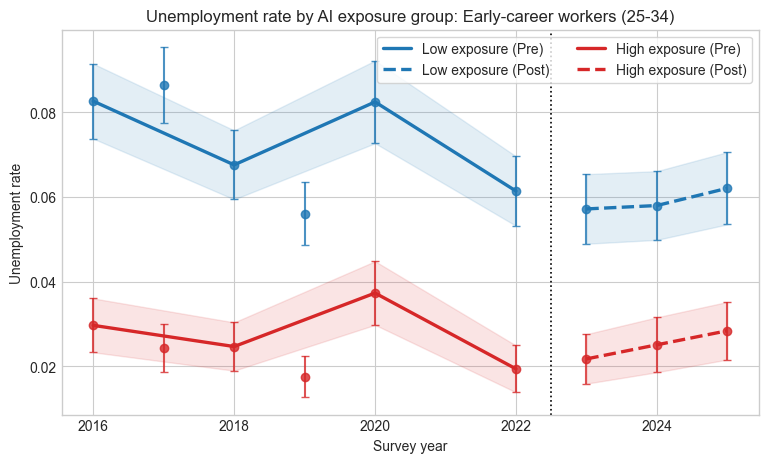

Saved causal_analysis_figures/03_weighted_unemployment_rate_by_ai_exposure_group_early_career_25_34.png


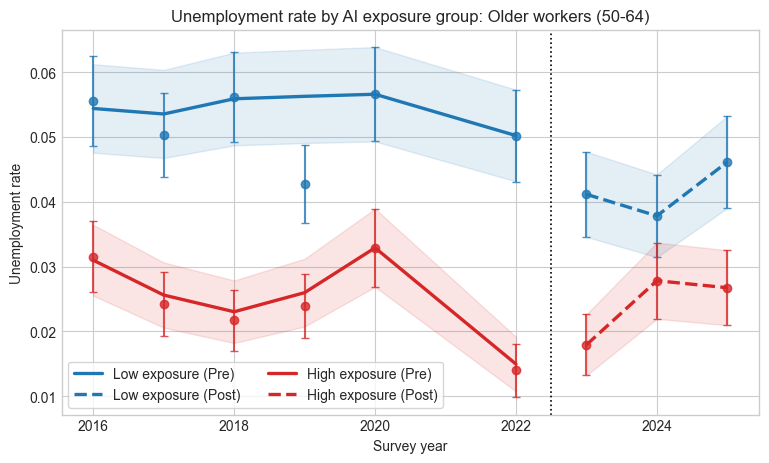

Saved causal_analysis_figures/04_weighted_unemployment_rate_by_ai_exposure_group_older_workers_50_64.png


In [13]:
figure_specs = [
    (
        "Early-career workers (25-34)",
        unemp_sample[unemp_sample["early_career"] == 1],
        "03_weighted_unemployment_rate_by_ai_exposure_group_early_career_25_34.png",
    ),
    (
        "Older workers (50-64)",
        unemp_sample[unemp_sample["older_worker"] == 1],
        "04_weighted_unemployment_rate_by_ai_exposure_group_older_workers_50_64.png",
    ),
]

for label, subset, filename in figure_specs:
    fig, ax, _ = plot_trends(
        subset,
        value_col="unemployed",
        title=f"Unemployment rate by AI exposure group: {label}",
        ylabel="Unemployment rate",
        post_start=2023,
    )
    plt.show()
    save_figure(fig, filename)


## Parallel Trends Check

The descriptive plots are useful for intuition, but they are not the identifying test for the DiD design. A stronger diagnostic is an event-study specification that replaces the single post-period interaction with year-specific interactions between `AIIE` and survey year.

This is **not** a staggered-adoption difference-in-differences design. The post period is common across industries; the event study simply asks whether industries with different `AIIE` values were already moving differently before the post-GenAI period.

For each outcome, the event-study specification is:

$$
Y_{it} = \alpha + \sum_{\tau \neq 2022} \beta_{\tau} \left(AIIE_j \times 1\{YEAR_t = \tau\}\right) + \gamma_j + \sum_{\tau \neq 2022} \lambda_{\tau} 1\{YEAR_t = \tau\} + \theta AGE_i + \sum_e \delta_e 1\{EDUC_i = e\} + \varepsilon_{it}
$$

with 2022 as the omitted reference year.

where:

- $Y_{it}$ is the outcome for individual $i$ in year $t$
- $AIIE_j$ is the AI Industry Exposure measure for industry $j$
- $\gamma_j$ are industry fixed effects
- $1\{YEAR_t = \tau\}$ is an indicator for survey year $\tau$
- $AGE_i$ is the worker's age
- $1\{EDUC_i = e\}$ are education-category indicators
- $\beta_{\tau}$ are the year-specific exposure coefficients used to evaluate pre-trends

How to interpret this check:

- If the pre-period coefficients are close to zero, that supports the parallel-trends assumption.
- If the pre-period coefficients are systematically different from zero, the design is less credible.
- The joint pre-trend test asks whether all pre-period `year × AIIE` coefficients are zero together.


In [14]:
from notebook_helpers import (
    fit_event_study,
    extract_event_study_table,
    joint_zero_test,
    plot_event_study_on_axis,
    plot_event_study,
)


### Parallel Trends for Unemployment

For unemployment, the DiD post period begins in 2023. The relevant pre-period years are 2016, 2017, 2018, 2019, 2020, and 2022, with 2022 omitted as the reference year.

Here the outcome is:

$$
Y_{it} = unemployed_{it}
$$

where `unemployed = 1` if the worker is unemployed and in the labor force.

A large p-value in the joint test would support parallel trends. A small p-value indicates that the pre-period `year × AIIE` coefficients are not jointly zero.


,term,year,coef,std_err,ci_low,ci_high,p_value
0,"C(YEAR, Treatment(reference=2022))[T.2016]:AIIE",2016,-0.0018,0.0019,-0.0056,0.0019,0.3423
1,"C(YEAR, Treatment(reference=2022))[T.2017]:AIIE",2017,-0.0016,0.0016,-0.0048,0.0015,0.3144
2,"C(YEAR, Treatment(reference=2022))[T.2018]:AIIE",2018,0.0000,0.0018,-0.0036,0.0036,0.9996
3,"C(YEAR, Treatment(reference=2022))[T.2019]:AIIE",2019,0.0022,0.0009,0.0005,0.0040,0.0131
4,"C(YEAR, Treatment(reference=2022))[T.2020]:AIIE",2020,-0.0016,0.0018,-0.0051,0.0019,0.3792
5,"C(YEAR, Treatment(reference=2022))[T.2023]:AIIE",2023,0.0016,0.0012,-0.0008,0.0040,0.1868
6,"C(YEAR, Treatment(reference=2022))[T.2024]:AIIE",2024,0.0039,0.0013,0.0014,0.0064,0.0025
7,"C(YEAR, Treatment(reference=2022))[T.2025]:AIIE",2025,0.0022,0.0013,-0.0004,0.0048,0.0934


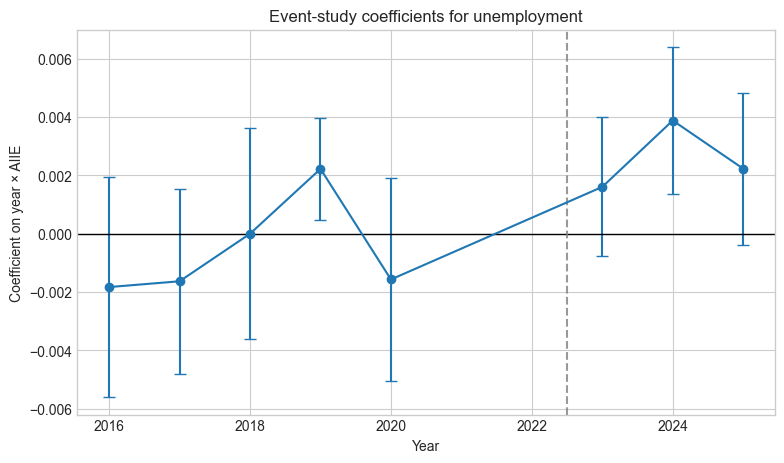

Saved causal_analysis_figures/05_event_study_coefficients_unemployment.png


,n_terms,wald_stat,p_value
0,5,18.8453,0.0021


In [15]:
unemp_event = fit_event_study(unemp_sample, "unemployed", reference_year=2022)
unemp_event_table = extract_event_study_table(unemp_event, reference_year=2022)

display(unemp_event_table)
fig_unemp_event, ax_unemp_event = plot_event_study(
    unemp_event_table,
    title="Event-study coefficients for unemployment",
    post_start=2023,
)
plt.show()
save_figure(fig_unemp_event, "05_event_study_coefficients_unemployment.png")

unemp_pre_terms = unemp_event_table.loc[
    unemp_event_table["year"] < 2023, "term"
].tolist()
joint_zero_test(unemp_event, unemp_pre_terms)


### Parallel Trends for Wages

For wages, the main DiD post period begins in 2024 because CPS ASEC wage income refers to the prior calendar year. The relevant pre-period years for the event study are therefore 2016, 2017, 2018, 2019, 2020, and 2022, again using 2022 as the omitted reference year.

Here the outcome is:

$$
Y_{it} = \log(wage_{it})
$$

where `log_wage = log(INCWAGE)` for employed workers with positive wage income.

The event study is estimated on the wage sample excluding 2023 so that it lines up with the main wage DiD sample.


,term,year,coef,std_err,ci_low,ci_high,p_value
0,"C(YEAR, Treatment(reference=2022))[T.2016]:AIIE",2016,-0.0218,0.0063,-0.0342,-0.0094,0.0006
1,"C(YEAR, Treatment(reference=2022))[T.2017]:AIIE",2017,-0.0186,0.0067,-0.0318,-0.0054,0.0057
2,"C(YEAR, Treatment(reference=2022))[T.2018]:AIIE",2018,-0.0231,0.0063,-0.0355,-0.0107,0.0003
3,"C(YEAR, Treatment(reference=2022))[T.2019]:AIIE",2019,-0.0194,0.0048,-0.0289,-0.0100,0.0001
4,"C(YEAR, Treatment(reference=2022))[T.2020]:AIIE",2020,-0.0065,0.0056,-0.0174,0.0044,0.2401
5,"C(YEAR, Treatment(reference=2022))[T.2024]:AIIE",2024,-0.0155,0.0060,-0.0274,-0.0037,0.0099
6,"C(YEAR, Treatment(reference=2022))[T.2025]:AIIE",2025,-0.0156,0.0056,-0.0266,-0.0047,0.0052


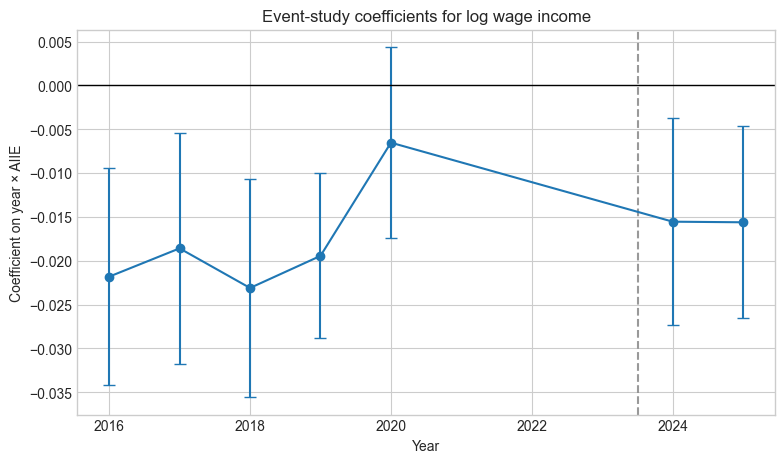

Saved causal_analysis_figures/06_event_study_coefficients_log_wage_income.png


,n_terms,wald_stat,p_value
0,5,30.7297,0.0000


In [16]:
wage_event = fit_event_study(wage_did_sample, "log_wage", reference_year=2022)
wage_event_table = extract_event_study_table(wage_event, reference_year=2022)

display(wage_event_table)
fig_wage_event, ax_wage_event = plot_event_study(
    wage_event_table,
    title="Event-study coefficients for log wage income",
    post_start=2024,
)
plt.show()
save_figure(fig_wage_event, "06_event_study_coefficients_log_wage_income.png")

wage_pre_terms = wage_event_table.loc[
    wage_event_table["year"] < 2024, "term"
].tolist()
joint_zero_test(wage_event, wage_pre_terms)


### Interpreting the Parallel Trends Results

The event-study coefficients above should be read as year-by-year deviations in the relationship between `AIIE` and the outcome, relative to 2022.

Two takeaways matter most:

1. The coefficients should be visually close to zero in the pre-period.
2. The joint pre-trend test should not strongly reject.

In the updated results, neither outcome fully clears that bar.

- **Unemployment:** most pre-period coefficients are small, but the 2019 coefficient is positive and statistically different from zero, and the joint pre-trend test rejects. That weakens a strict causal interpretation.
- **Wages:** the pre-period coefficients are more consistently negative and statistically different from zero from 2016 through 2019, and the joint test rejects more strongly.

The practical conclusion is therefore cautious:

- the unemployment specification remains more informative than the wage specification because its pre-period departures are smaller and less systematic
- the unemployment results should still be described as suggestive rather than definitive causal estimates
- the wage results are the weakest design because the pre-period drift is persistent


## DiD Regressions: Unemployment

We estimate:

$$
unemployed_{it} = \beta_0 + \beta_1 AIIE_j + \beta_2 post^{unemp}_t + \beta_3 \left(AIIE_j \times post^{unemp}_t\right) + \beta_4 AGE_i + \sum_e \delta_e 1\{EDUC_i = e\} + \varepsilon_{it}
$$

where:

- $unemployed_{it}$ equals 1 if person $i$ is unemployed in year $t$
- $AIIE_j$ is the AI exposure of industry $j$
- $post^{unemp}_t$ equals 1 for years 2023-2025 and 0 otherwise
- $AGE_i$ is the worker's age
- $1\{EDUC_i = e\}$ are education-category indicators
- $\beta_3$ is the main DiD coefficient of interest

The heterogeneity model adds a triple interaction with `early_career`:

$$
unemployed_{it} = \alpha_0 + \alpha_1 AIIE_j + \alpha_2 post^{unemp}_t + \alpha_3 early\_career_i + \alpha_4 \left(AIIE_j \times post^{unemp}_t\right)
 + \alpha_5 \left(AIIE_j \times early\_career_i\right) + \alpha_6 \left(post^{unemp}_t \times early\_career_i\right) + \alpha_7 \left(AIIE_j \times post^{unemp}_t \times early\_career_i\right) + \alpha_8 AGE_i + \sum_e \rho_e 1\{EDUC_i = e\} + u_{it}
$$

Additional variable definitions for the heterogeneity model:

- $early\_career_i$ equals 1 if worker $i$ is age 25-34 and 0 otherwise
- $\alpha_7$ tests whether the post-period exposure effect differs for ages 25-34 relative to ages 35-64


In [17]:
# base DiD
m_unemp_base = run_wls(
    "unemployed ~ AIIE * post_unemployment + AGE + C(EDUC)",
    unemp_sample,
)
coef_table(m_unemp_base, keep="AIIE|post")

,coef,std_err,p_value
AIIE,-0.0078,0.0015,0.0000
post_unemployment,-0.0046,0.0014,0.0015
AIIE:post_unemployment,0.0029,0.0012,0.0143


In [18]:
# triple interaction: AIIE x post x early_career
m_unemp_triple = run_wls(
    "unemployed ~ AIIE * post_unemployment * early_career + AGE + C(EDUC)",
    unemp_sample,
)
coef_table(m_unemp_triple, keep="AIIE|post|early")

,coef,std_err,p_value
AIIE,-0.0060,0.0017,0.0005
post_unemployment,-0.0040,0.0015,0.0080
AIIE:post_unemployment,0.0020,0.0013,0.1306
early_career,0.0083,0.0013,0.0000
AIIE:early_career,-0.0066,0.0013,0.0000
post_unemployment:early_career,-0.0019,0.0016,0.2318
AIIE:post_unemployment:early_career,0.0034,0.0013,0.0099


## DiD Regressions: Wages

We estimate:

$$
\log(wage_{it}) = \alpha_0 + \alpha_1 AIIE_j + \alpha_2 post^{wage}_t + \alpha_3 \left(AIIE_j \times post^{wage}_t\right) + \alpha_4 AGE_i + \sum_e \rho_e 1\{EDUC_i = e\} + u_{it}
$$

where:

- $\log(wage_{it})$ is log annual wage income for worker $i$ in year $t$
- $AIIE_j$ is the AI exposure of industry $j$
- $post^{wage}_t$ equals 1 for years 2024-2025 and 0 otherwise
- $AGE_i$ is the worker's age
- $1\{EDUC_i = e\}$ are education-category indicators
- $\alpha_3$ is the main DiD coefficient of interest

The wage heterogeneity model parallels the unemployment triple-interaction specification:

$$
\log(wage_{it}) = \eta_0 + \eta_1 AIIE_j + \eta_2 post^{wage}_t + \eta_3 early\_career_i + \eta_4 \left(AIIE_j \times post^{wage}_t\right)
+ \eta_5 \left(AIIE_j \times early\_career_i\right) + \eta_6 \left(post^{wage}_t \times early\_career_i\right) + \eta_7 \left(AIIE_j \times post^{wage}_t \times early\_career_i\right) + \eta_8 AGE_i + \sum_e \phi_e 1\{EDUC_i = e\} + \omega_{it}
$$

This uses `post_wage` (2024+) to account for the CPS ASEC timing offset and excludes 2023 as a transition year from the main wage DiD sample.


In [19]:
m_wage_base = run_wls(
    "log_wage ~ AIIE * post_wage + AGE + C(EDUC)",
    wage_did_sample,
)
coef_table(m_wage_base, keep="AIIE|post")

,coef,std_err,p_value
AIIE,0.0162,0.0459,0.7246
post_wage,0.2394,0.0072,0.0000
AIIE:post_wage,0.0026,0.0074,0.7297


In [20]:
m_wage_triple = run_wls(
    "log_wage ~ AIIE * post_wage * early_career + AGE + C(EDUC)",
    wage_did_sample,
)
coef_table(m_wage_triple, keep="AIIE|post|early")

,coef,std_err,p_value
AIIE,0.0190,0.0469,0.6853
post_wage,0.2253,0.0075,0.0000
AIIE:post_wage,-0.0010,0.0081,0.8975
early_career,-0.1838,0.0126,0.0000
AIIE:early_career,-0.0087,0.0193,0.6512
post_wage:early_career,0.0484,0.0096,0.0000
AIIE:post_wage:early_career,0.0123,0.0077,0.1092


## Event Studies

Interact `AIIE` with year dummies (ref = 2022) to inspect pre-trends and the timing of any post-treatment shift.


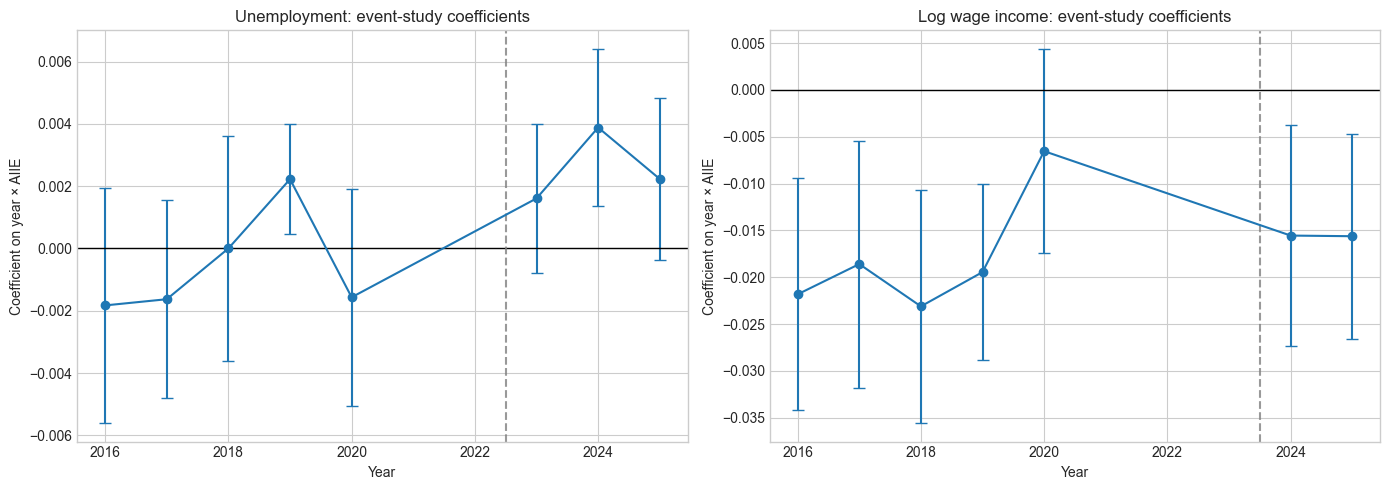

Saved causal_analysis_figures/07_event_studies_unemployment_and_log_wage_combined.png


In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_event_study_on_axis(
    unemp_event_table,
    ax1,
    "Unemployment: event-study coefficients",
    post_start=2023,
)
plot_event_study_on_axis(
    wage_event_table,
    ax2,
    "Log wage income: event-study coefficients",
    post_start=2024,
)
plt.tight_layout()
plt.show()
save_figure(fig, "07_event_studies_unemployment_and_log_wage_combined.png")


## Robustness Checks

1. Drop 2020 (COVID shock)
2. Event study without 2020


In [22]:
# robustness: drop 2020
unemp_no20 = unemp_sample[unemp_sample["YEAR"] != 2020].copy()
wage_no20 = wage_did_sample[wage_did_sample["YEAR"] != 2020].copy()

m_unemp_no20 = run_wls(
    "unemployed ~ AIIE * post_unemployment * early_career + AGE + C(EDUC)",
    unemp_no20,
)
m_wage_no20 = run_wls(
    "log_wage ~ AIIE * post_wage * early_career + AGE + C(EDUC)",
    wage_no20,
)

display(coef_table(m_unemp_no20, keep="AIIE|post|early"))
display(coef_table(m_wage_no20, keep="AIIE|post|early"))

unemp_no20_event = fit_event_study(unemp_no20, "unemployed", reference_year=2022)
unemp_no20_event_table = extract_event_study_table(unemp_no20_event, reference_year=2022)
wage_no20_event = fit_event_study(wage_no20, "log_wage", reference_year=2022)
wage_no20_event_table = extract_event_study_table(wage_no20_event, reference_year=2022)


,coef,std_err,p_value
AIIE,-0.0058,0.0019,0.0019
post_unemployment,-0.0022,0.0016,0.1646
AIIE:post_unemployment,0.0016,0.0013,0.2140
early_career,0.0087,0.0015,0.0000
AIIE:early_career,-0.0069,0.0015,0.0000
post_unemployment:early_career,-0.0017,0.0017,0.2919
AIIE:post_unemployment:early_career,0.0037,0.0014,0.0078


,coef,std_err,p_value
AIIE,0.0167,0.0465,0.7194
post_wage,0.2346,0.0077,0.0000
AIIE:post_wage,0.0012,0.0085,0.8927
early_career,-0.1817,0.0137,0.0000
AIIE:early_career,-0.0085,0.0194,0.6615
post_wage:early_career,0.0469,0.0100,0.0000
AIIE:post_wage:early_career,0.0120,0.0083,0.1488


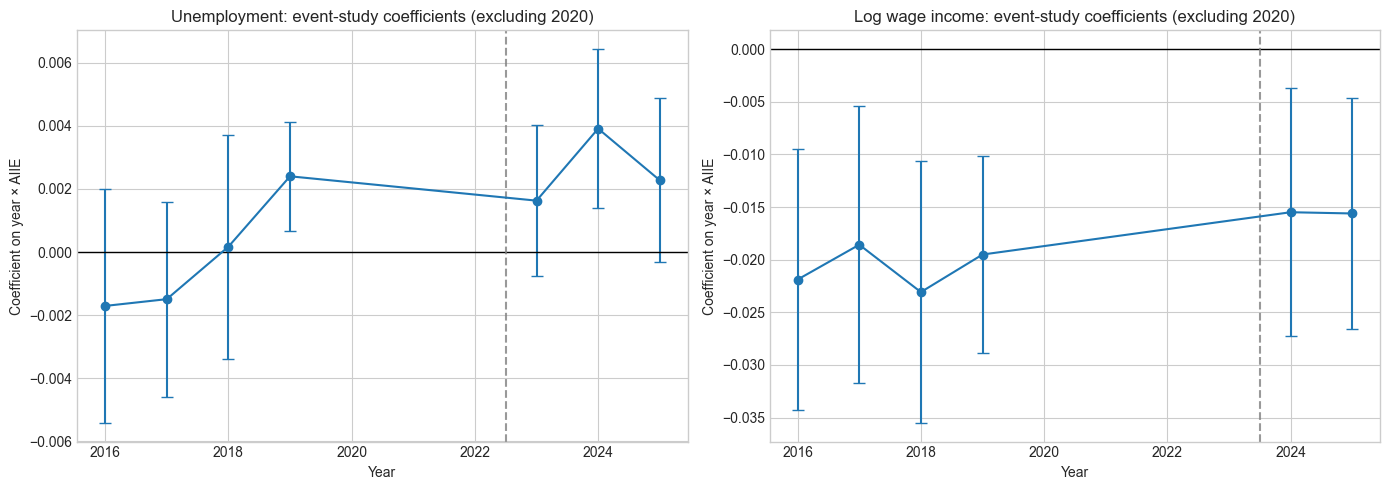

Saved causal_analysis_figures/08_event_studies_unemployment_and_log_wage_no_2020_combined.png


In [23]:
# event studies without 2020
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_event_study_on_axis(
    unemp_no20_event_table,
    ax1,
    "Unemployment: event-study coefficients (excluding 2020)",
    post_start=2023,
)
plot_event_study_on_axis(
    wage_no20_event_table,
    ax2,
    "Log wage income: event-study coefficients (excluding 2020)",
    post_start=2024,
)
plt.tight_layout()
plt.show()
save_figure(fig, "08_event_studies_unemployment_and_log_wage_no_2020_combined.png")


## Age Heterogeneity: 25-29 vs 30-34 vs 35+

Anthropic (2025) finds hiring slowdowns concentrated in the youngest workers. The split below checks whether the estimated unemployment shift is statistically different for ages 25-29 versus ages 30-34, rather than relying on whether one coefficient happens to be individually significant and the other does not.


In [24]:
unemp_sample["age_group"] = pd.cut(
    unemp_sample["AGE"],
    bins=[24, 29, 34, 64],
    labels=["25-29", "30-34", "35-64"],
)

m_age_split = run_wls(
    "unemployed ~ AIIE * post_unemployment * C(age_group, Treatment(reference='35-64'))"
    " + AGE + C(EDUC)",
    unemp_sample,
)

key_terms = [
    k
    for k in m_age_split.params.index
    if "AIIE:post_unemployment:C(age_group" in k
]
age_split_table = coef_table(m_age_split).loc[key_terms].copy()

term_25_29 = next(k for k in key_terms if "[T.25-29]" in k)
term_30_34 = next(k for k in key_terms if "[T.30-34]" in k)
age_gap_test = wald_difference_test(
    m_age_split,
    term_25_29,
    term_30_34,
    "25-29 coefficient minus 30-34 coefficient",
)

display(age_split_table)
display(age_gap_test)


,coef,std_err,p_value
"AIIE:post_unemployment:C(age_group, Treatment(reference='35-64'))[T.25-29]",0.0045,0.0020,0.0274
"AIIE:post_unemployment:C(age_group, Treatment(reference='35-64'))[T.30-34]",0.0024,0.0017,0.1712


,comparison,difference,wald_stat,p_value
0,25-29 coefficient minus 30-34 coefficient,0.0022,0.6477,0.4210


## Interpretation

**Baseline unemployment result.** The main unemployment DiD coefficient on `AIIE × post_unemployment` is positive and statistically significant at about `0.0029` (`p = 0.014`). Higher-AI-exposure industries still have lower unemployment on average, but their relative unemployment advantage narrows after 2023.

**Younger workers show a larger relative shift.** In the heterogeneity model, the triple interaction `AIIE × post_unemployment × early_career` is positive and statistically significant at about `0.0034` (`p = 0.010`). That means the post-2023 relative unemployment shift is larger for workers ages 25-34 than for workers ages 35-64.

**The 25-29 estimate is larger, but not statistically different from 30-34.** In the age-split model, the `25-29` coefficient is about `0.0045` (`p = 0.027`) and the `30-34` coefficient is about `0.0024` (`p = 0.171`). However, the difference between those two coefficients is not statistically significant (`p = 0.421`). The age split is therefore suggestive, but it does not justify a strong claim that the effect is uniquely concentrated in ages 25-29.

**No detectable wage effect appears in the current data.** Across wage specifications, the `AIIE × post_wage` terms remain small and statistically insignificant. The short post period and weaker pre-trend performance make the wage results especially tentative.

**Parallel-trends concerns remain.** The unemployment event study is easier to reconcile with the DiD design than the wage event study because the pre-period departures are smaller and less systematic. Even so, the unemployment joint pre-trend test rejects, so the unemployment estimates should be framed as suggestive rather than definitive causal effects.

**What the design can and cannot say.** The results indicate that younger workers in higher-AI-exposure industries experienced weaker post-2023 unemployment outcomes. The current design does not cleanly distinguish whether that pattern comes from reduced hiring, slower job-finding, greater layoffs, or a combination of those channels.
